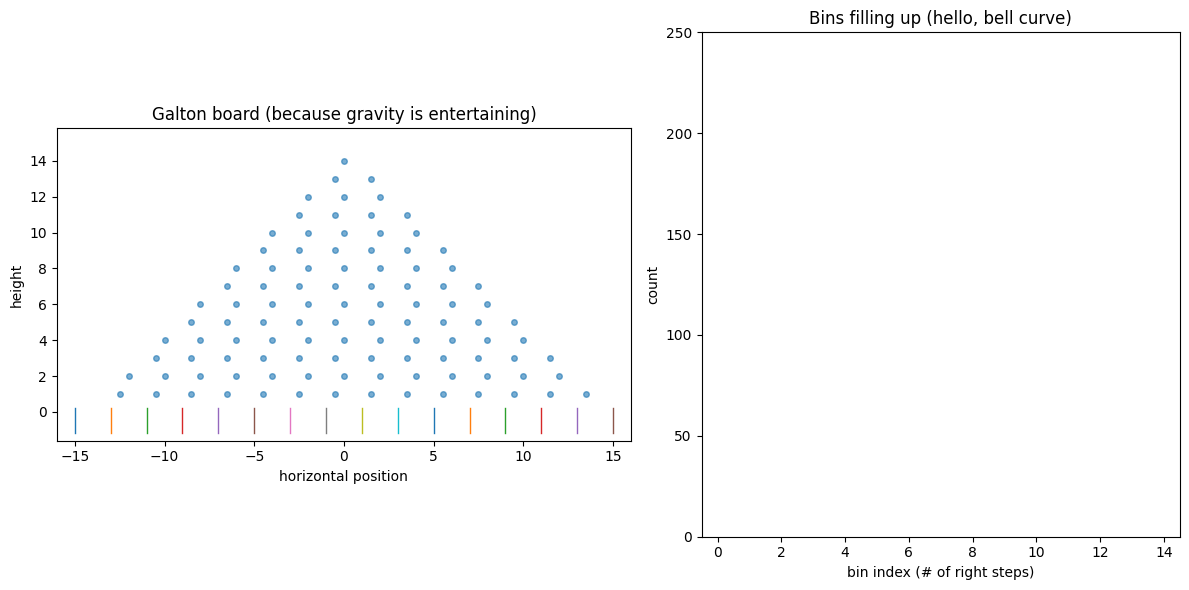

MovieWriter ffmpeg unavailable; using Pillow instead.
c:\Users\User\AppData\Local\Programs\Python\Python314\Lib\site-packages\matplotlib\animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation

def make_paths(n_balls, n_layers, p_right=0.5, seed=0):
    """
    Precompute left/right decisions and the resulting x-positions at each layer.
    Returns:
      x_nodes: (n_balls, n_layers+1) x at each node (start + after each layer)
      bin_idx: (n_balls,) final bin index in [0..n_layers]
    """
    rng = np.random.default_rng(seed)
    # steps: True = right, False = left
    steps = rng.random((n_balls, n_layers)) < p_right
    # Map to -1/+1
    dx = np.where(steps, 1, -1)
    # Node positions (start at 0)
    x_nodes = np.zeros((n_balls, n_layers + 1), dtype=float)
    x_nodes[:, 1:] = np.cumsum(dx, axis=1)
    # Convert final x to bin index: x = -n_layers, -n_layers+2, ..., +n_layers
    # bin index = (x + n_layers)/2
    bin_idx = ((x_nodes[:, -1] + n_layers) / 2).astype(int)
    return x_nodes, bin_idx

def build_timeline(x_nodes, n_layers, frames_per_layer=8, fall_extra_frames=10, release_every=2):
    """
    Build a frame-by-frame position array for all balls.
    Balls are released (start falling) staggered by release_every frames.

    Returns:
      pos: (T, n_balls, 2) float array, NaN for not-yet-released balls
      landed_frame: (n_balls,) frame index when the ball lands
    """
    n_balls = x_nodes.shape[0]
    # y levels: start above top pegs, then each peg row, then bottom
    y_start = n_layers + 1.0
    y_nodes = np.linspace(y_start, 0.0, n_layers + 1)  # length n_layers+1 nodes
    # After last peg interaction, give it a little extra fall time into bins
    y_bottom = -1.2

    # Total frames per ball (not counting release delay)
    core_frames = n_layers * frames_per_layer + fall_extra_frames
    # Total animation frames with staggering
    T = core_frames + (n_balls - 1) * release_every

    pos = np.full((T, n_balls, 2), np.nan, dtype=float)
    landed_frame = np.zeros(n_balls, dtype=int)

    for b in range(n_balls):
        start_t = b * release_every

        # Segment-by-segment interpolation through layers
        t = start_t
        for layer in range(n_layers):
            x0 = x_nodes[b, layer]
            x1 = x_nodes[b, layer + 1]
            y0 = y_nodes[layer]
            y1 = y_nodes[layer + 1]

            # Interpolate this segment
            for f in range(frames_per_layer):
                a = (f + 1) / frames_per_layer
                # Slight horizontal "bounce" wiggle so it doesn't look dead inside
                wiggle = 0.08 * np.sin(np.pi * a) * (1 if (layer % 2 == 0) else -1)
                pos[t, b, 0] = (1 - a) * x0 + a * x1 + wiggle
                pos[t, b, 1] = (1 - a) * y0 + a * y1
                t += 1

        # Extra fall into bins (straight down)
        x_last = x_nodes[b, -1]
        y_last = y_nodes[-1]
        for f in range(fall_extra_frames):
            a = (f + 1) / fall_extra_frames
            pos[t, b, 0] = x_last
            pos[t, b, 1] = (1 - a) * y_last + a * y_bottom
            t += 1

        landed_frame[b] = t - 1

    return pos, landed_frame

def animate_galton(
    n_balls=400,
    n_layers=12,
    p_right=0.5,
    frames_per_layer=8,
    fall_extra_frames=10,
    release_every=2,
    seed=2
):
    # Precompute random paths
    x_nodes, bin_idx = make_paths(n_balls, n_layers, p_right=p_right, seed=seed)
    pos, landed_frame = build_timeline(
        x_nodes,
        n_layers,
        frames_per_layer=frames_per_layer,
        fall_extra_frames=fall_extra_frames,
        release_every=release_every
    )
    T = pos.shape[0]

    # Counts per bin for the histogram
    counts = np.zeros(n_layers + 1, dtype=int)
    landed = np.zeros(n_balls, dtype=bool)

    # ---- Figure layout: left = board, right = histogram
    fig = plt.figure(figsize=(12, 6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.2, 1.0])

    ax_board = fig.add_subplot(gs[0, 0])
    ax_hist = fig.add_subplot(gs[0, 1])

    # ---- Draw pegs
    # Peg rows at y = n_layers..1 (ish), with alternating x offsets
    peg_x = []
    peg_y = []
    for r in range(n_layers):
        y = n_layers - r
        # number of pegs increases each row
        n_pegs = r + 1
        # centered x positions with offset so rows interleave visually
        xs = np.linspace(-r, r, n_pegs)
        # small alternating shift to look like a typical peg layout
        xs = xs + (0.5 if (r % 2 == 1) else 0.0)
        peg_x.extend(xs)
        peg_y.extend([y] * n_pegs)

    ax_board.scatter(peg_x, peg_y, s=16, alpha=0.6)

    # ---- Draw bin walls (tubes)
    # Valid final x are -n_layers, -n_layers+2, ..., +n_layers
    # Bin boundaries in x are at odd integers between them
    # We'll draw vertical lines at boundaries:
    boundaries = np.arange(-n_layers - 1, n_layers + 2, 2)  # e.g. -13,-11,...,+13 for n_layers=12
    for xb in boundaries:
        ax_board.plot([xb, xb], [-1.2, 0.2], linewidth=1)

    # Board cosmetics
    ax_board.set_title("Galton board (because gravity is entertaining)")
    ax_board.set_xlim(-n_layers - 2, n_layers + 2)
    ax_board.set_ylim(-1.6, n_layers + 1.8)
    ax_board.set_xlabel("horizontal position")
    ax_board.set_ylabel("height")
    ax_board.set_aspect("equal", adjustable="box")

    # Balls scatter
    balls_scatter = ax_board.scatter([], [], s=18)

    # ---- Histogram setup
    bins = np.arange(n_layers + 1)
    bars = ax_hist.bar(bins, counts, width=0.9)
    ax_hist.set_title("Bins filling up (hello, bell curve)")
    ax_hist.set_xlabel("bin index (# of right steps)")
    ax_hist.set_ylabel("count")
    ax_hist.set_xlim(-0.5, n_layers + 0.5)
    ax_hist.set_ylim(0, max(10, int(n_balls * 0.25)))

    info_text = ax_hist.text(
        0.02, 0.95, "", transform=ax_hist.transAxes,
        va="top", ha="left"
    )

    def init():
        balls_scatter.set_offsets(np.empty((0, 2)))
        for bar in bars:
            bar.set_height(0)
        info_text.set_text("")
        return [balls_scatter, *bars, info_text]

    def update(frame):
        nonlocal counts, landed

        # Update ball positions for this frame (ignore NaNs = not released)
        xy = pos[frame]
        valid = ~np.isnan(xy[:, 0])
        balls_scatter.set_offsets(xy[valid])

        # Check which balls have just landed by this frame
        newly_landed = (~landed) & (landed_frame == frame)
        if np.any(newly_landed):
            idxs = np.where(newly_landed)[0]
            landed[idxs] = True
            # increment histogram bins for these balls
            for b in idxs:
                counts[bin_idx[b]] += 1

            # Resize y-limit if needed
            current_max = counts.max()
            if current_max > ax_hist.get_ylim()[1] * 0.95:
                ax_hist.set_ylim(0, int(current_max * 1.25) + 1)

        # Update bars
        for k, bar in enumerate(bars):
            bar.set_height(counts[k])

        info_text.set_text(f"Balls landed: {landed.sum()} / {n_balls}\nLayers: {n_layers}, p_right={p_right}")

        return [balls_scatter, *bars, info_text]

    anim = FuncAnimation(
        fig, update, frames=T, init_func=init,
        interval=30, blit=False, repeat=False
    )

    plt.tight_layout()
    plt.show()
    return anim

if __name__ == "__main__":
    anim=animate_galton(
        n_balls=1000,      # increase for smoother Gaussian
        n_layers=14,      # more layers -> more bell-shaped
        p_right=0.5,      # symmetric
        frames_per_layer=7,
        fall_extra_frames=10,
        release_every=2,
        seed=7
    )
    anim.save("animation.gif")
